# IEQ Tuned All-Model Comparison

This notebook compares the tuned IEQ model families using one fixed validation protocol. The hyperparameters are already selected before this notebook starts; the purpose here is to re-run the models under matched five-fold cross-validation, save the out-of-fold predictions, and create article-ready tables and figures.

The main selection metric is macro F1 because the dissatisfied and neutral classes are much smaller than the satisfied class. Accuracy, balanced accuracy, and ordinal MAE are kept as supporting diagnostics.

## 1. Setup

Import the analysis packages, load the shared manuscript plotting style from `paper_style.py`, and define the fixed model configurations used in this comparison. All later figures use the same color palette and helper functions as the paper figures.

In [1]:
from __future__ import annotations

import platform
import sys
import time
import warnings
from pathlib import Path

import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, f1_score, mean_absolute_error
from sklearn.model_selection import StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    from IPython.display import display # type: ignore
except ModuleNotFoundError:
    def display(value):
        print(value)

warnings.filterwarnings("ignore", category=ConvergenceWarning)


STYLE_DIR = Path.cwd()
for root in [Path.cwd(), *Path.cwd().parents]:
    candidate = root / "03_Code" / "ieq_paper" / "01_notebook"
    if (candidate / "paper_style.py").exists():
        STYLE_DIR = candidate.resolve()
        break
if str(STYLE_DIR) not in sys.path:
    sys.path.insert(0, str(STYLE_DIR))
from paper_style import COLORS as PAPER_COLORS, MODEL_PALETTE, apply_paper_style, plot_confusion_matrix, save_figure, style_axes

apply_paper_style()
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)

SEED = 20260507
N_SPLITS = 5
TARGET = "IEQ satisfaction 3-class"
DROP_FROM_FEATURES = [TARGET, "TimeVote"]
CLASS_ORDER = ["dissatisfied", "neutral", "satisfied"]
CLASS_TO_NUMBER = {label: index for index, label in enumerate(CLASS_ORDER)}
CLASS_DISPLAY_LABELS = ["Dissatisfied", "Neutral", "Satisfied"]
PERFORMANCE_METRICS = ["macro_f1", "accuracy", "balanced_accuracy", "weighted_f1", "ordinal_mae"]
DOMAIN_IMPORTANCE_REPEATS = 5
RAW_IMPORTANCE_TOP_N = 15
RUN_FINAL_MODEL_FIT = False
FEATURE_CATEGORIES = {
    "Thermal environment": ["Temperature", "RH", "CLO", "Ttrend", "AC on/off"],
    "Indoor air quality": ["CO2"],
    "Lighting": ["Lighting"],
    "Acoustic": ["Sound"],
    "Occupant / schedule": ["Student", "Age", "Gender", "EA", "Vote hour", "Vote weekday", "Moment"],
    "Classroom position": ["LocationBack", "LocationFront", "LocationLeft", "LocationRight", "LocationMiddle"],
}

MODEL_ORDER = ["Logistic regression", "Random Forest", "Extra Trees", "Gradient boosting", "ANN / MLP"]
SELECTED_MODEL = "Extra Trees"
MODEL_COLORS = {
    "Logistic regression": PAPER_COLORS["dark_blue"],
    "Random Forest": PAPER_COLORS["secondary_green"],
    "Extra Trees": PAPER_COLORS["best"],
    "Gradient boosting": PAPER_COLORS["medium"],
    "ANN / MLP": PAPER_COLORS["purple"],
}
MODEL_DISPLAY_LABELS = {
    "Logistic regression": "Logistic\nregression",
    "Random Forest": "Random\nForest",
    "Extra Trees": "Extra\nTrees",
    "Gradient boosting": "Gradient\nboosting",
    "ANN / MLP": "ANN /\nMLP",
}
def show_or_close(fig) -> None:
    if "ipykernel" in sys.modules:
        plt.show()
    else:
        plt.close(fig)


FINAL_MODEL_CONFIGS = {
    "Logistic regression": {
        "estimator": LogisticRegression(C=0.03, class_weight="balanced", solver="lbfgs", max_iter=3000, random_state=SEED),
        "selected_params": {"C": 0.03, "class_weight": "balanced", "solver": "lbfgs"},
    },
    "Random Forest": {
        "estimator": RandomForestClassifier(
            n_estimators=300,
            criterion="gini",
            max_depth=None,
            max_features="sqrt",
            min_samples_leaf=4,
            min_samples_split=10,
            class_weight="balanced_subsample",
            n_jobs=1,
            random_state=SEED,
        ),
        "selected_params": {
            "n_estimators": 300,
            "criterion": "gini",
            "max_depth": None,
            "max_features": "sqrt",
            "min_samples_leaf": 4,
            "min_samples_split": 10,
            "class_weight": "balanced_subsample",
        },
    },
    "Extra Trees": {
        "estimator": ExtraTreesClassifier(
            n_estimators=500,
            criterion="entropy",
            bootstrap=True,
            max_samples=0.9,
            max_features=None, # type: ignore
            max_depth=None,
            min_samples_leaf=2,
            min_samples_split=10,
            class_weight="balanced",
            n_jobs=1,
            random_state=SEED,
        ),
        "selected_params": {
            "n_estimators": 500,
            "criterion": "entropy",
            "bootstrap": True,
            "max_samples": 0.9,
            "max_features": None,
            "max_depth": None,
            "min_samples_leaf": 2,
            "min_samples_split": 10,
            "class_weight": "balanced",
        },
    },
    "Gradient boosting": {
        "estimator": GradientBoostingClassifier(
            n_estimators=220,
            learning_rate=0.08,
            max_depth=3,
            max_features=None,
            min_samples_leaf=10,
            subsample=0.85,
            random_state=SEED,
        ),
        "selected_params": {
            "n_estimators": 220,
            "learning_rate": 0.08,
            "max_depth": 3,
            "max_features": None,
            "min_samples_leaf": 10,
            "subsample": 0.85,
        },
    },
    "ANN / MLP": {
        "estimator": MLPClassifier(
            hidden_layer_sizes=(64, 32),
            activation="tanh",
            alpha=0.001,
            learning_rate_init=0.003,
            batch_size=64,
            max_iter=400,
            early_stopping=False,
            random_state=SEED,
        ),
        "selected_params": {
            "hidden_layer_sizes": (64, 32),
            "activation": "tanh",
            "alpha": 0.001,
            "learning_rate_init": 0.003,
            "batch_size": 64,
        },
    },
}

print("Python:", platform.python_version())
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("Random seed:", SEED)
print("Style file:", STYLE_DIR / "paper_style.py")


Python: 3.13.5
pandas: 2.2.3
numpy: 2.1.3
scikit-learn: 1.6.1
Random seed: 20260507
Style file: C:\Users\Dell Latitude 5540\OneDrive - VUT\12. semestr\ML\Prism\03_Code\ieq_paper\01_notebook\paper_style.py


## 2. Load Dataset

Locate the model-ready IEQ dataset, create the output folder, and load the data table. The notebook is written so it can be run from the repository root or directly from the notebook folder.

In [2]:
DATASET_FILE_NAME = "ieq_model_dataset.xlsx"
DATASET_RELATIVE_PATH = Path("02_Datasets") / "model_ready" / DATASET_FILE_NAME


def find_dataset_path() -> Path:
    candidates = []
    for root in [Path.cwd(), *Path.cwd().parents]:
        candidates.extend(
            [
                root / DATASET_RELATIVE_PATH,
                root / "Prism" / DATASET_RELATIVE_PATH,
                root / DATASET_FILE_NAME,
            ]
        )
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError(
        "Could not find ieq_model_dataset.xlsx. Keep the Prism folder structure, "
        "or place ieq_model_dataset.xlsx in the current working folder."
    )


DATASET_PATH = find_dataset_path()
if DATASET_PATH.parent.name == "model_ready" and DATASET_PATH.parent.parent.name == "02_Datasets":
    PROJECT_ROOT = DATASET_PATH.parent.parent.parent
    OUTPUT_DIR = PROJECT_ROOT / "03_Code" / "ieq_paper" / "02_outputs" / "all_models_comparison"
    PAPER_FIGURE_DIR = PROJECT_ROOT / "04_Figures"
else:
    OUTPUT_DIR = Path.cwd() / "all_models_comparison_outputs"
    PAPER_FIGURE_DIR = Path.cwd() / "paper_figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PAPER_FIGURE_DIR.mkdir(parents=True, exist_ok=True)


def save_current_figure(fig, name: str) -> None:
    output_path = OUTPUT_DIR / name
    save_figure(fig, output_path)
    print("Saved", output_path.with_suffix(".png"))
    print("Saved", output_path.with_suffix(".pdf"))
    
    paper_path = PAPER_FIGURE_DIR / name
    save_figure(fig, paper_path)
    print("Saved paper figure:", paper_path.with_suffix(".png"))
    print("Saved paper figure:", paper_path.with_suffix(".pdf"))

data = pd.read_excel(DATASET_PATH, sheet_name="data")

print("Dataset:", DATASET_PATH)
print("Rows, columns:", data.shape)
display(data.head())


Dataset: C:\Users\Dell Latitude 5540\OneDrive - VUT\12. semestr\ML\Prism\02_Datasets\model_ready\ieq_model_dataset.xlsx
Rows, columns: (6834, 22)


,TimeVote,Student,IEQ satisfaction 3-class,Temperature,RH,CLO,CO2,Lighting,Sound,Age,Gender,EA,LocationBack,LocationFront,LocationLeft,LocationRight,LocationMiddle,Ttrend,Vote hour,Vote weekday,Moment,AC on/off
0,21/04/2021 10:29,Student,dissatisfied,23.683,31.015,0.64,743,214.567,60.004,15,Male,38.09,True,False,False,True,False,-0.072,10,Wednesday,Start,False
1,21/04/2021 10:29,Student,neutral,23.683,31.015,0.64,743,214.567,60.004,15,Male,38.09,True,False,False,True,False,-0.072,10,Wednesday,Start,False
2,21/04/2021 10:29,Student,neutral,23.683,31.015,0.64,743,214.567,60.004,16,Female,38.09,True,False,False,True,False,-0.072,10,Wednesday,Start,False
3,21/04/2021 10:30,Student,neutral,23.683,31.015,0.81,743,214.567,60.004,16,Female,38.09,True,False,False,False,True,-0.072,10,Wednesday,Start,False
4,21/04/2021 10:30,Student,dissatisfied,23.683,31.015,0.64,743,214.567,60.004,16,Female,38.09,False,True,False,True,False,-0.072,10,Wednesday,Start,True


## 3. Select Predictors

Remove the target and timestamp column from the predictor matrix, then separate numeric and categorical predictors for fold-internal preprocessing. The domain table documents how raw predictors are grouped for the permutation-importance audit.

In [3]:
feature_columns = [column for column in data.columns if column not in DROP_FROM_FEATURES]

X = data[feature_columns].copy()
y = data[TARGET].astype(str)

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = [column for column in X.columns if column not in numeric_features]

print("Target:", TARGET)
print("Number of predictors:", len(feature_columns))
print("Numeric predictors:", numeric_features)
print("Categorical / boolean predictors:", categorical_features)
print("Class distribution:")
display(y.value_counts().reindex(CLASS_ORDER).rename("rows").to_frame())

category_feature_map = {
    category: [feature for feature in features if feature in feature_columns]
    for category, features in FEATURE_CATEGORIES.items()
}
category_feature_map = {category: features for category, features in category_feature_map.items() if features}
domain_feature_map = {feature: [feature] for feature in feature_columns}
domain_feature_table = pd.DataFrame(
    [
        {"domain": category, "n_features": len(features), "features": ", ".join(features)}
        for category, features in category_feature_map.items()
    ]
)
with pd.option_context("display.max_colwidth", None, "display.max_rows", None):
    display(domain_feature_table)

Target: IEQ satisfaction 3-class
Number of predictors: 20
Numeric predictors: ['Temperature', 'RH', 'CLO', 'CO2', 'Lighting', 'Sound', 'Age', 'EA', 'Ttrend', 'Vote hour']
Categorical / boolean predictors: ['Student', 'Gender', 'LocationBack', 'LocationFront', 'LocationLeft', 'LocationRight', 'LocationMiddle', 'Vote weekday', 'Moment', 'AC on/off']
Class distribution:


,rows
IEQ satisfaction 3-class,
dissatisfied,484
neutral,1855
satisfied,4495


,domain,n_features,features
0,Thermal environment,5,"Temperature, RH, CLO, Ttrend, AC on/off"
1,Indoor air quality,1,CO2
2,Lighting,1,Lighting
3,Acoustic,1,Sound
4,Occupant / schedule,7,"Student, Age, Gender, EA, Vote hour, Vote weekday, Moment"
5,Classroom position,5,"LocationBack, LocationFront, LocationLeft, LocationRight, LocationMiddle"


## 4. Model Pipelines

Build one scikit-learn pipeline per model. Each pipeline first standardizes numeric features and one-hot encodes categorical features, then fits the model with the fixed tuned hyperparameters listed below.

These are not searched in this notebook. They are the selected settings being compared under the same validation protocol.

In [4]:
def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def make_preprocessor():
    return ColumnTransformer(
        transformers=[
            ("numeric", StandardScaler(), numeric_features),
            ("categorical", make_one_hot_encoder(), categorical_features),
        ],
        remainder="drop",
    )


def make_model(model_name: str):
    return clone(FINAL_MODEL_CONFIGS[model_name]["estimator"])


def make_pipeline(model_name: str):
    return Pipeline(
        steps=[
            ("preprocess", make_preprocessor()),
            ("model", make_model(model_name)),
        ]
    )


model_parameter_rows = []
for model_name in MODEL_ORDER:
    for parameter, value in FINAL_MODEL_CONFIGS[model_name]["selected_params"].items():
        model_parameter_rows.append(
            {
                "model": model_name,
                "parameter": parameter,
                "value": value,
            }
        )

model_parameters = pd.DataFrame(model_parameter_rows)
display(model_parameters)

,model,parameter,value
0,Logistic regression,C,0.03
1,Logistic regression,class_weight,balanced
2,Logistic regression,solver,lbfgs
3,Random Forest,n_estimators,300
4,Random Forest,criterion,gini
5,Random Forest,max_depth,None
6,Random Forest,max_features,sqrt
7,Random Forest,min_samples_leaf,4
8,Random Forest,min_samples_split,10
9,Random Forest,class_weight,balanced_subsample


## 5. Five-Fold Validation

Run stratified five-fold cross-validation for every tuned model. Preprocessing and model fitting happen inside each training fold, and predictions are collected only for the held-out fold. This creates out-of-fold predictions for fair metric calculation and confusion matrices.

The grouped permutation importance calculation is an audit: each raw predictor is shuffled on the validation fold and the macro F1 drop is recorded. It is not used for model selection.

In [5]:
def ordinal_mae(y_true, y_pred):
    true_numbers = pd.Series(y_true).map(CLASS_TO_NUMBER).to_numpy()
    pred_numbers = pd.Series(y_pred).map(CLASS_TO_NUMBER).to_numpy()
    return float(mean_absolute_error(true_numbers, pred_numbers))


def evaluate_predictions(y_true, y_pred):
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
        "ordinal_mae": float(ordinal_mae(y_true, y_pred)),
    }


def grouped_domain_permutation_rows(pipeline, X_test, y_test, baseline_macro_f1, model_name, fold):
    rows = []
    model_offset = MODEL_ORDER.index(model_name) + 1
    rng = np.random.default_rng(SEED + model_offset * 10000 + fold * 1000)
    for domain, domain_features in domain_feature_map.items():
        feature_list = ", ".join(domain_features)
        for repeat in range(1, DOMAIN_IMPORTANCE_REPEATS + 1):
            shuffled_positions = rng.permutation(len(X_test))
            X_permuted = X_test.copy()
            for feature in domain_features:
                X_permuted[feature] = X_permuted[feature].iloc[shuffled_positions].to_numpy()
            permuted_pred = pipeline.predict(X_permuted)
            permuted_macro_f1 = float(f1_score(y_test, permuted_pred, average="macro", zero_division=0))
            rows.append(
                {
                    "model": model_name,
                    "fold": fold,
                    "repeat": repeat,
                    "domain": domain,
                    "features": feature_list,
                    "baseline_macro_f1": baseline_macro_f1,
                    "permuted_macro_f1": permuted_macro_f1,
                    "macro_f1_drop": baseline_macro_f1 - permuted_macro_f1,
                }
            )
    return rows


cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
fold_rows = []
prediction_rows = []
domain_importance_rows = []

for model_name in MODEL_ORDER:
    print(f"Evaluating {model_name}...")
    for fold, (train_index, test_index) in enumerate(cv.split(X, y), start=1):
        pipeline = make_pipeline(model_name)
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        start = time.perf_counter()
        pipeline.fit(X_train, y_train)
        fit_seconds = time.perf_counter() - start

        start = time.perf_counter()
        y_pred = pipeline.predict(X_test)
        predict_seconds = time.perf_counter() - start

        metrics = evaluate_predictions(y_test, y_pred)
        domain_importance_rows.extend(grouped_domain_permutation_rows(pipeline, X_test, y_test, metrics["macro_f1"], model_name, fold))
        fold_rows.append(
            {
                "model": model_name,
                "fold": fold,
                "train_rows": len(train_index),
                "test_rows": len(test_index),
                **metrics,
                "fit_seconds": fit_seconds,
                "predict_seconds": predict_seconds,
                "total_seconds": fit_seconds + predict_seconds,
            }
        )

        for source_index, true_label, predicted_label in zip(test_index, y_test, y_pred):
            prediction_rows.append(
                {
                    "model": model_name,
                    "source_index": int(source_index),
                    "fold": fold,
                    "y_true": true_label,
                    "y_pred": predicted_label,
                }
            )

fold_results = pd.DataFrame(fold_rows)
cv_predictions = pd.DataFrame(prediction_rows)
domain_importance = pd.DataFrame(domain_importance_rows)
domain_importance_summary = (
    domain_importance
    .groupby(["model", "domain", "features"], as_index=False)
    .agg(
        importance_mean=("macro_f1_drop", "mean"),
        importance_std=("macro_f1_drop", "std"),
        baseline_macro_f1_mean=("baseline_macro_f1", "mean"),
        permuted_macro_f1_mean=("permuted_macro_f1", "mean"),
    )
)
domain_importance_summary["model"] = pd.Categorical(domain_importance_summary["model"], categories=MODEL_ORDER, ordered=True)
domain_importance_summary = domain_importance_summary.sort_values(["model", "importance_mean"], ascending=[True, False]).reset_index(drop=True)

summary = fold_results.groupby("model")[PERFORMANCE_METRICS].agg(["mean", "std"])
summary.columns = [f"{metric}_{stat}" for metric, stat in summary.columns]
summary = summary.reset_index()
summary["model"] = pd.Categorical(summary["model"], categories=MODEL_ORDER, ordered=True)
summary = summary.sort_values("model").reset_index(drop=True)
fold_metrics = fold_results[["model", "fold", "train_rows", "test_rows", *PERFORMANCE_METRICS]].copy()

display(summary.sort_values("macro_f1_mean", ascending=False))

Evaluating Logistic regression...


Evaluating Random Forest...


Evaluating Extra Trees...


Evaluating Gradient boosting...


Evaluating ANN / MLP...


,model,macro_f1_mean,macro_f1_std,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,weighted_f1_mean,weighted_f1_std,ordinal_mae_mean,ordinal_mae_std
2,Extra Trees,0.594899,0.029792,0.723440,0.008820,0.595710,0.036153,0.720933,0.010647,0.314604,0.008282
1,Random Forest,0.589730,0.019711,0.716710,0.007010,0.592292,0.025578,0.712449,0.007849,0.322064,0.012261
3,Gradient boosting,0.497618,0.021422,0.696370,0.007792,0.473351,0.015854,0.655572,0.010458,0.345333,0.009474
4,ANN / MLP,0.495458,0.014997,0.652619,0.009433,0.492983,0.016537,0.650328,0.010540,0.399766,0.011819
0,Logistic regression,0.402469,0.011456,0.483464,0.010829,0.467676,0.017145,0.521560,0.009794,0.668716,0.005536


## 6. Confusion Matrices

Use the out-of-fold predictions from Section 5 to create row-normalized confusion matrices. Rows show the true class, columns show the predicted class, and each cell reports both the count and row percentage.

The figure is saved without a top-level title and without grid lines so it can be inserted directly into the article.

,dissatisfied,neutral,satisfied
dissatisfied,206,143,135
neutral,172,972,711
satisfied,125,604,3766


Saved C:\Users\Dell Latitude 5540\OneDrive - VUT\12. semestr\ML\Prism\03_Code\ieq_paper\02_outputs\all_models_comparison\all_models_confusion_matrices.png
Saved C:\Users\Dell Latitude 5540\OneDrive - VUT\12. semestr\ML\Prism\03_Code\ieq_paper\02_outputs\all_models_comparison\all_models_confusion_matrices.pdf


Saved paper figure: C:\Users\Dell Latitude 5540\OneDrive - VUT\12. semestr\ML\Prism\04_Figures\all_models_confusion_matrices.png
Saved paper figure: C:\Users\Dell Latitude 5540\OneDrive - VUT\12. semestr\ML\Prism\04_Figures\all_models_confusion_matrices.pdf


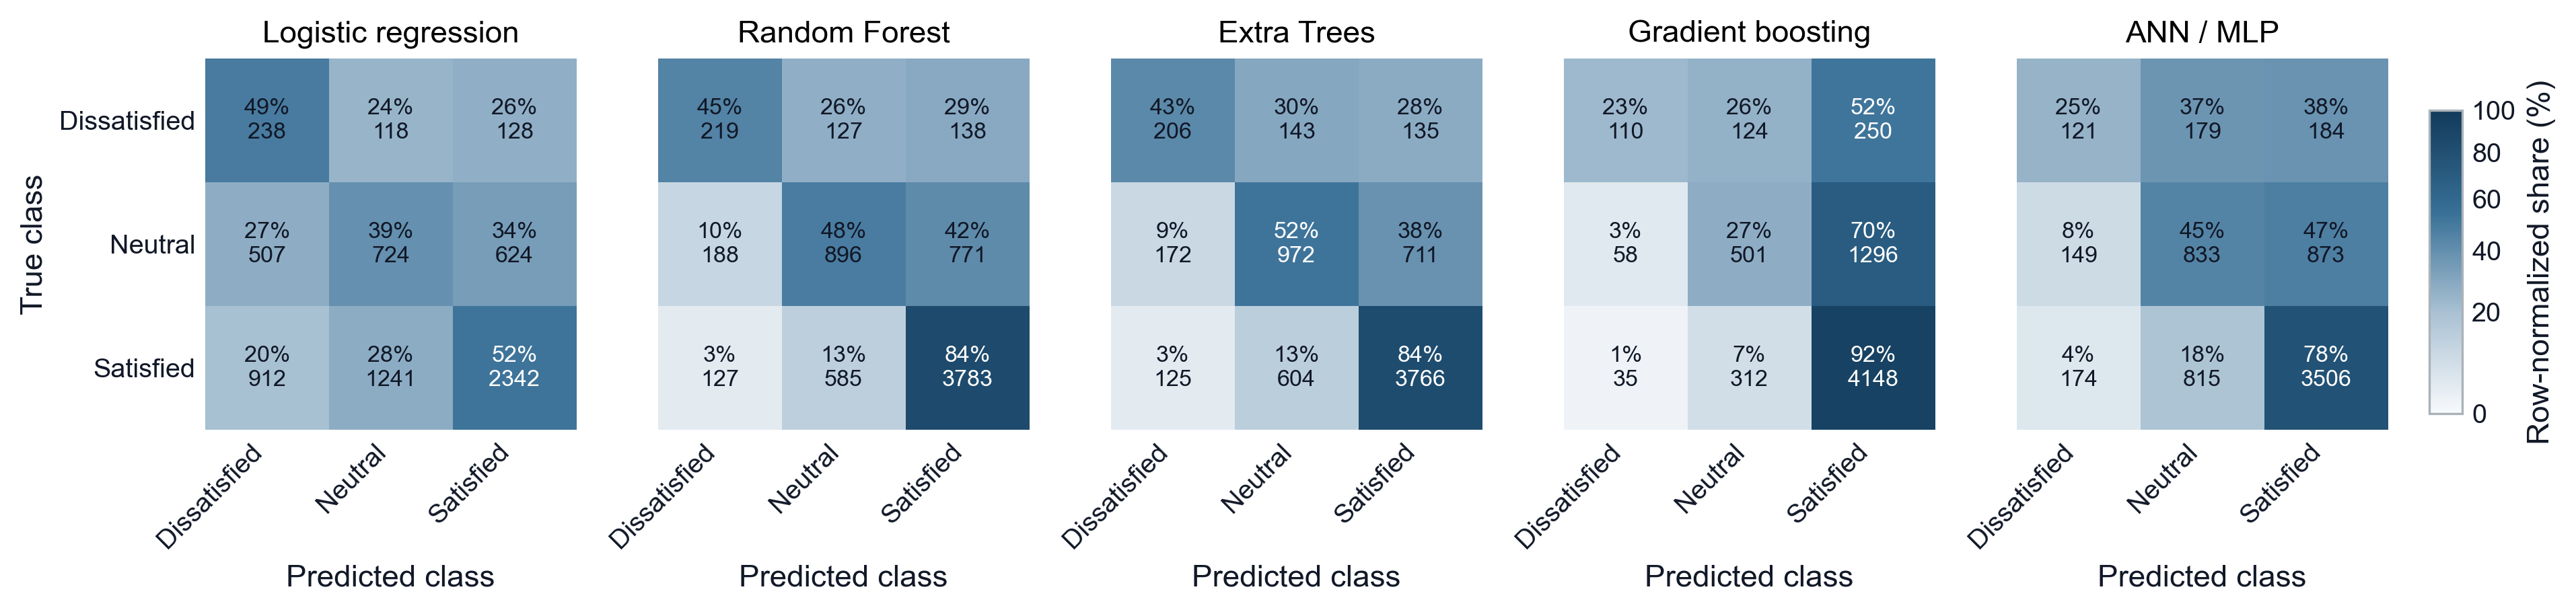

Saved outputs to: C:\Users\Dell Latitude 5540\OneDrive - VUT\12. semestr\ML\Prism\03_Code\ieq_paper\02_outputs\all_models_comparison


In [6]:
confusion_tables = {}
confusion_rows = []
for model_name in MODEL_ORDER:
    model_predictions = cv_predictions.loc[cv_predictions["model"].eq(model_name)]
    confusion = pd.DataFrame(
        confusion_matrix(model_predictions["y_true"], model_predictions["y_pred"], labels=CLASS_ORDER),
        index=CLASS_ORDER,
        columns=CLASS_ORDER,
    )
    confusion_tables[model_name] = confusion
    row_totals = confusion.sum(axis=1).replace(0, np.nan)
    confusion_percent = confusion.div(row_totals, axis=0).fillna(0) * 100
    for true_label in CLASS_ORDER:
        for pred_label in CLASS_ORDER:
            confusion_rows.append(
                {
                    "model": model_name,
                    "true_class": true_label,
                    "predicted_class": pred_label,
                    "count": int(confusion.loc[true_label, pred_label]),
                    "row_percent": float(confusion_percent.loc[true_label, pred_label]),
                }
            )

confusion_long = pd.DataFrame(confusion_rows)

fold_metrics.to_csv(OUTPUT_DIR / "all_models_5fold_folds.csv", index=False)
summary.to_csv(OUTPUT_DIR / "all_models_5fold_summary.csv", index=False)
cv_predictions.to_csv(OUTPUT_DIR / "all_models_5fold_predictions.csv", index=False)
confusion_long.to_csv(OUTPUT_DIR / "all_models_confusion_matrices.csv", index=False)
model_parameters.to_csv(OUTPUT_DIR / "all_models_fixed_hyperparameters.csv", index=False)
domain_importance.to_csv(OUTPUT_DIR / "all_models_domain_importance_folds.csv", index=False)
domain_importance_summary.to_csv(OUTPUT_DIR / "all_models_domain_importance_summary.csv", index=False)

display(confusion_tables[SELECTED_MODEL])

fig, axes = plt.subplots(nrows=1, ncols=len(MODEL_ORDER), figsize=(13.6, 3.5), sharex=True, sharey=True)
image = None
for ax, model_name in zip(axes, MODEL_ORDER):
    image, colorbar_label = plot_confusion_matrix(
        ax,
        confusion_tables[model_name],
        labels=CLASS_ORDER,
        display_labels=CLASS_DISPLAY_LABELS,
        title=MODEL_DISPLAY_LABELS[model_name].replace("\n", " "),
        annotation_fontsize=8.2,
    )

for ax in axes[1:]:
    ax.set_ylabel("")

fig.subplots_adjust(wspace=0.22, bottom=0.28, top=0.82, right=0.92)
colorbar_axis = fig.add_axes([0.935, 0.31, 0.012, 0.43])
colorbar = fig.colorbar(image, cax=colorbar_axis)
colorbar.set_label(colorbar_label)
save_current_figure(fig, "all_models_confusion_matrices")
show_or_close(fig)

print("Saved outputs to:", OUTPUT_DIR.resolve())


## 7. Model Comparison

Create the compact comparison table and article-ready performance figure. The table is sorted by macro F1, and the plot uses the shared `paper_style.py` colors rather than ad hoc notebook colors.

The figure is saved without a top-level title or explanatory caption text so it can be placed directly in the manuscript layout.

,model,macro_f1,accuracy,balanced_accuracy,ordinal_mae
0,Extra Trees,0.5949,0.7234,0.5957,0.3146
1,Random Forest,0.5897,0.7167,0.5923,0.3221
2,Gradient boosting,0.4976,0.6964,0.4734,0.3453
3,ANN / MLP,0.4955,0.6526,0.4930,0.3998
4,Logistic regression,0.4025,0.4835,0.4677,0.6687


Saved C:\Users\Dell Latitude 5540\OneDrive - VUT\12. semestr\ML\Prism\03_Code\ieq_paper\02_outputs\all_models_comparison\all_models_comparison.png
Saved C:\Users\Dell Latitude 5540\OneDrive - VUT\12. semestr\ML\Prism\03_Code\ieq_paper\02_outputs\all_models_comparison\all_models_comparison.pdf


Saved paper figure: C:\Users\Dell Latitude 5540\OneDrive - VUT\12. semestr\ML\Prism\04_Figures\all_models_comparison.png
Saved paper figure: C:\Users\Dell Latitude 5540\OneDrive - VUT\12. semestr\ML\Prism\04_Figures\all_models_comparison.pdf


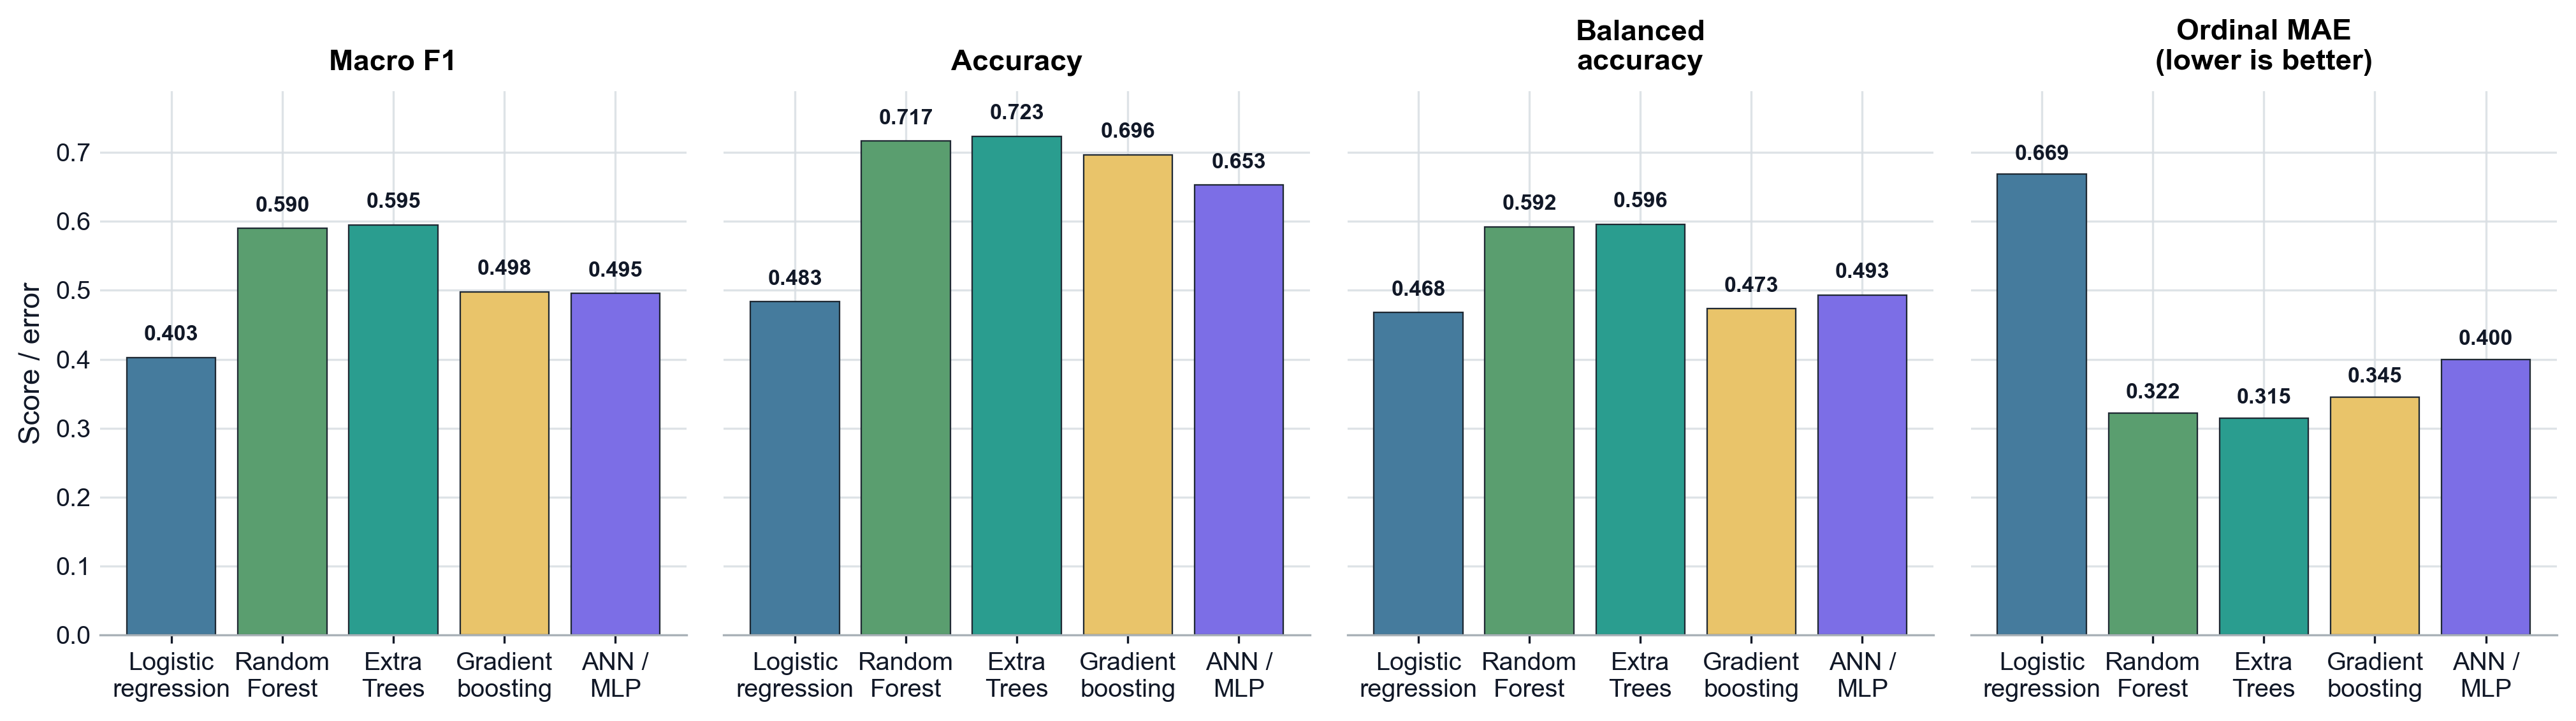

In [7]:
comparison_results = summary[[
    "model",
    "macro_f1_mean",
    "accuracy_mean",
    "balanced_accuracy_mean",
    "ordinal_mae_mean",
]].copy()
comparison_results = comparison_results.rename(
    columns={
        "macro_f1_mean": "macro_f1",
        "accuracy_mean": "accuracy",
        "balanced_accuracy_mean": "balanced_accuracy",
        "ordinal_mae_mean": "ordinal_mae",
    }
)
comparison_results = comparison_results.sort_values("macro_f1", ascending=False).reset_index(drop=True)

for column in ["macro_f1", "accuracy", "balanced_accuracy", "ordinal_mae"]:
    comparison_results[column] = comparison_results[column].round(4)

display(comparison_results)

COMPARISON_PLOT_METRICS = ["macro_f1", "accuracy", "balanced_accuracy", "ordinal_mae"]
metric_labels = {
    "macro_f1": "Macro F1",
    "accuracy": "Accuracy",
    "balanced_accuracy": "Balanced\naccuracy",
    "ordinal_mae": "Ordinal MAE\n(lower is better)",
}

plot_data = comparison_results.set_index("model").reindex(MODEL_ORDER).reset_index()
model_labels = plot_data["model"].tolist()
x_positions = np.arange(len(model_labels))
bar_colors = [MODEL_COLORS[model] for model in model_labels]

fig, axes = plt.subplots(ncols=len(COMPARISON_PLOT_METRICS), figsize=(13.6, 3.9), sharey=True)
for ax, metric in zip(axes, COMPARISON_PLOT_METRICS):
    values = plot_data[metric].astype(float).to_numpy()
    bars = ax.bar(
        x_positions,
        values,
        color=bar_colors,
        edgecolor=PAPER_COLORS["border"],
        linewidth=0.55,
    )
    ax.set_title(metric_labels[metric], fontsize=11, fontweight="bold", pad=8)
    ax.set_xticks(x_positions)
    ax.set_xticklabels([MODEL_DISPLAY_LABELS[model] for model in model_labels])
    if metric == "ordinal_mae":
        ax.set_ylim(0, max(values) * 1.18)
    else:
        ax.set_ylim(0, 1.0)
    style_axes(ax, grid_axis="y")
    for bar, value in zip(bars, values):
        label_y = value + ax.get_ylim()[1] * 0.018
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            label_y,
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=8.2,
            fontweight="bold",
            color=PAPER_COLORS["text"],
        )

axes[0].set_ylabel("Score / error")
for ax in axes[1:]:
    ax.tick_params(axis="y", labelleft=False)

fig.tight_layout()
save_current_figure(fig, "all_models_comparison")
show_or_close(fig)

comparison_results.to_csv(OUTPUT_DIR / "all_models_comparison.csv", index=False)

## 8. Optional Final Model Fit

The comparison above uses out-of-fold predictions, so it does not need a final fit on the full dataset. A full-data `fit` is only useful if you want trained pipeline objects for later export or manual inspection after the comparison is finished.

By default this optional step is disabled (`RUN_FINAL_MODEL_FIT = False`) because the notebook does not save the fitted pipelines and the estimator HTML output can make the notebook large. Set it to `True` only when you explicitly need in-memory final models in the current session.

In [8]:
final_models = {}
final_fit_summary = pd.DataFrame(columns=["model", "training_rows", "predictors", "fit_seconds"])

if RUN_FINAL_MODEL_FIT:
    final_fit_rows = []
    for model_name in MODEL_ORDER:
        pipeline = make_pipeline(model_name)
        start = time.perf_counter()
        pipeline.fit(X, y)
        fit_seconds = time.perf_counter() - start
        final_models[model_name] = pipeline
        final_fit_rows.append(
            {
                "model": model_name,
                "training_rows": len(X),
                "predictors": len(feature_columns),
                "fit_seconds": fit_seconds,
            }
        )

    final_fit_summary = pd.DataFrame(final_fit_rows)
    display(final_fit_summary)
    print("Trained final fixed models on all rows:", ", ".join(final_models.keys()))
else:
    print("Skipped final full-data fit. Set RUN_FINAL_MODEL_FIT = True in Section 1 if trained in-memory pipelines are needed.")

Skipped final full-data fit. Set RUN_FINAL_MODEL_FIT = True in Section 1 if trained in-memory pipelines are needed.
